# Responsible AI & Model Evaluation — Titanic Classification

Comprehensive evaluation of a Random Forest classifier beyond aggregate accuracy, including confusion matrices, classification reports, subgroup fairness analysis by Sex, and SHAP explainability.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
os.environ["MPLCONFIGDIR"] = "/tmp/mplconfig-exp10"

import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shap
import joblib
from IPython.display import Image, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

# Robust path discovery
current = Path.cwd().resolve()
monorepo_root = None
for parent in [current] + list(current.parents):
    if (parent / "DL Experiment 1" / "titanic-pipeline" / "src" / "pipeline.py").exists():
        monorepo_root = parent
        break

if monorepo_root is None:
    raise RuntimeError("Could not find DL-Experiments repository root containing Experiment 1.")

project_root = monorepo_root / "DL Experiment 10" / "responsible-ai-evaluation"
exp1_src = monorepo_root / "DL Experiment 1" / "titanic-pipeline" / "src"
exp1_data = monorepo_root / "DL Experiment 1" / "titanic-pipeline" / "data" / "raw" / "titanic.csv"

reports_dir = project_root / "reports"
models_dir = project_root / "models"
reports_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Import pipeline from Experiment 1
sys.path.insert(0, str(exp1_src))
from pipeline import TitanicPreprocessor, get_titanic_data, split_data

print("Project Root:", project_root)
print("Experiment 1 src added to sys.path:", exp1_src)
print("SHAP version:", shap.__version__)


Project Root: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation
Experiment 1 src added to sys.path: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 1/titanic-pipeline/src
SHAP version: 0.51.0


## Section 1: Load Data and Reuse Experiment 1 Pipeline

In [2]:
# Load dataset using reused function
df = get_titanic_data(path=str(exp1_data))
print("Raw dataset shape:", df.shape)

# Preprocess and engineer features using reused TitanicPreprocessor
pre = TitanicPreprocessor()
df = pre.extract_title(df)
df = pre.clean(df)
df = pre.feature_engineer(df)

# Stratified 70/15/15 train/val/test split
train_df, val_df, test_df = split_data(df)

y_train = train_df["Survived"]
y_val = val_df["Survived"]
y_test = test_df["Survived"]

# Transform features using ColumnTransformer
X_train_processed = pre.fit_transform(train_df)
X_val_processed = pre.transform(val_df)
X_test_processed = pre.transform(test_df)

feature_names = list(pre.preprocessor.get_feature_names_out())

print("\n--- Split & Processed Shapes ---")
print("Training Set:   ", X_train_processed.shape, "Labels:", y_train.shape)
print("Validation Set: ", X_val_processed.shape, "Labels:", y_val.shape)
print("Testing Set:    ", X_test_processed.shape, "Labels:", y_test.shape)
print(f"Number of transformed features: {len(feature_names)}")

Raw dataset shape: (891, 12)

--- Split & Processed Shapes ---
Training Set:    (623, 26) Labels: (623,)
Validation Set:  (134, 26) Labels: (134,)
Testing Set:     (134, 26) Labels: (134,)
Number of transformed features: 26


## Section 2: Train Classifier

In [3]:
# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_processed, y_train)

# Predict on test set
y_pred = clf.predict(X_test_processed)
overall_acc = accuracy_score(y_test, y_pred)

print("RandomForestClassifier trained successfully (n_estimators=200, random_state=42).")
print(f"Test Set Accuracy: {overall_acc:.4f} ({overall_acc * 100:.2f}%)")

RandomForestClassifier trained successfully (n_estimators=200, random_state=42).
Test Set Accuracy: 0.7761 (77.61%)


## Section 3: Confusion Matrix and Classification Report

Confusion Matrix:
[[71 12]
 [18 33]]

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.86      0.83        83
    Survived       0.73      0.65      0.69        51

    accuracy                           0.78       134
   macro avg       0.77      0.75      0.76       134
weighted avg       0.77      0.78      0.77       134

Saved classification report to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/classification_report.csv


Saved confusion matrix heatmap to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/confusion_matrix.png


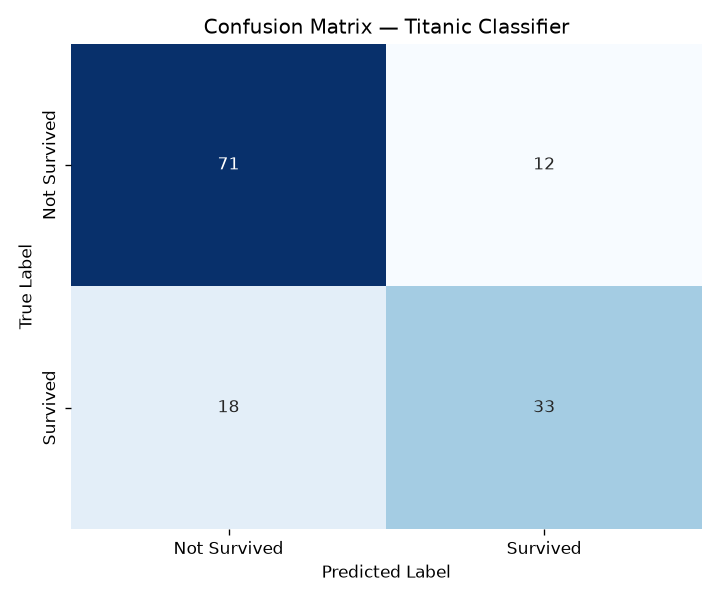

In [4]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 2. Classification Report
target_names = ["Not Survived", "Survived"]
cr_text = classification_report(y_test, y_pred, target_names=target_names)
print("\nClassification Report:")
print(cr_text)

# Export report to DataFrame and CSV
cr_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
cr_df = pd.DataFrame(cr_dict).transpose()
cr_path = reports_dir / "classification_report.csv"
cr_df.to_csv(cr_path)
print(f"Saved classification report to: {cr_path}")

# 3. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False,
)
plt.title("Confusion Matrix — Titanic Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_plot_path = reports_dir / "confusion_matrix.png"
plt.savefig(cm_plot_path, dpi=120)
plt.close()
print(f"Saved confusion matrix heatmap to: {cm_plot_path}")
display(Image(filename=str(cm_plot_path)))

## Section 4: Bias Detection by Sensitive Attribute (Sex)

--- Subgroup Accuracy Bias Report by Sex ---
   Sex  accuracy  total_samples  correct_predictions
female  0.791667             48                   38
  male  0.767442             86                   66

Saved bias report to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/bias_report.csv

--- Detailed Fairness Metrics by Subgroup ---
   Sex  Accuracy  Precision  Recall  F1-Score  Support
female    0.7917     0.8235  0.8750    0.8485       48
  male    0.7674     0.4545  0.2632    0.3333       86

Saved fairness metrics by group to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/fairness_metrics_by_group.csv
Saved bias bar chart to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/bias_by_sex.png


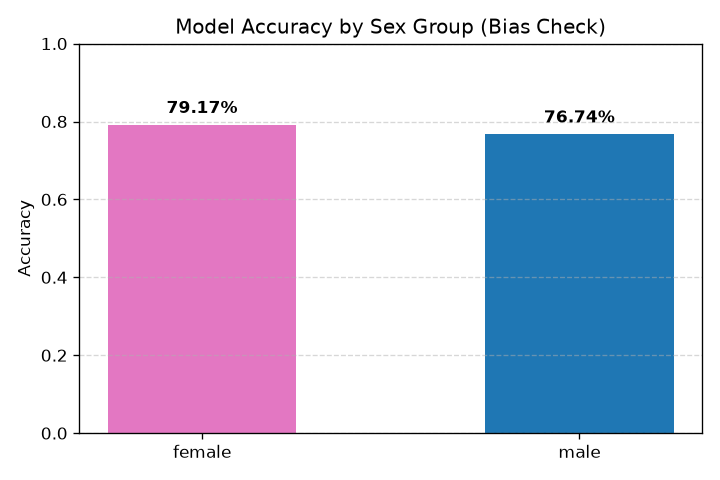

In [5]:
# Build evaluation DataFrame from UN-processed test_df so 'Sex' is readable
eval_df = test_df.copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = y_pred
eval_df["correct"] = (eval_df["actual"] == eval_df["predicted"]).astype(int)

# Group by 'Sex' and compute accuracy metrics
bias_report = eval_df.groupby("Sex")["correct"].agg(
    accuracy="mean",
    total_samples="count",
    correct_predictions="sum",
).reset_index()

bias_csv_path = reports_dir / "bias_report.csv"
bias_report.to_csv(bias_csv_path, index=False)
print("--- Subgroup Accuracy Bias Report by Sex ---")
print(bias_report.to_string(index=False))
print(f"\nSaved bias report to: {bias_csv_path}")

# Subgroup precision/recall/F1 metrics
fairness_records = []
for sex_group, group_data in eval_df.groupby("Sex"):
    acc = accuracy_score(group_data["actual"], group_data["predicted"])
    p, r, f1, _ = precision_recall_fscore_support(
        group_data["actual"], group_data["predicted"], average="binary", zero_division=0
    )
    fairness_records.append({
        "Sex": sex_group,
        "Accuracy": round(acc, 4),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1-Score": round(f1, 4),
        "Support": len(group_data),
    })
fairness_df = pd.DataFrame(fairness_records)
fairness_csv_path = reports_dir / "fairness_metrics_by_group.csv"
fairness_df.to_csv(fairness_csv_path, index=False)
print("\n--- Detailed Fairness Metrics by Subgroup ---")
print(fairness_df.to_string(index=False))
print(f"\nSaved fairness metrics by group to: {fairness_csv_path}")

# Subgroup accuracy bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(bias_report["Sex"], bias_report["accuracy"], color=["#E377C2", "#1F77B4"], width=0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy by Sex Group (Bias Check)")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.2%}", ha="center", va="bottom", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
bias_plot_path = reports_dir / "bias_by_sex.png"
plt.savefig(bias_plot_path, dpi=120)
plt.close()
print(f"Saved bias bar chart to: {bias_plot_path}")
display(Image(filename=str(bias_plot_path)))

## Section 5: Model Explainability with SHAP

SHAP values shape for 'Survived' class: (134, 26)
Saved SHAP summary plot to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/reports/shap_summary.png


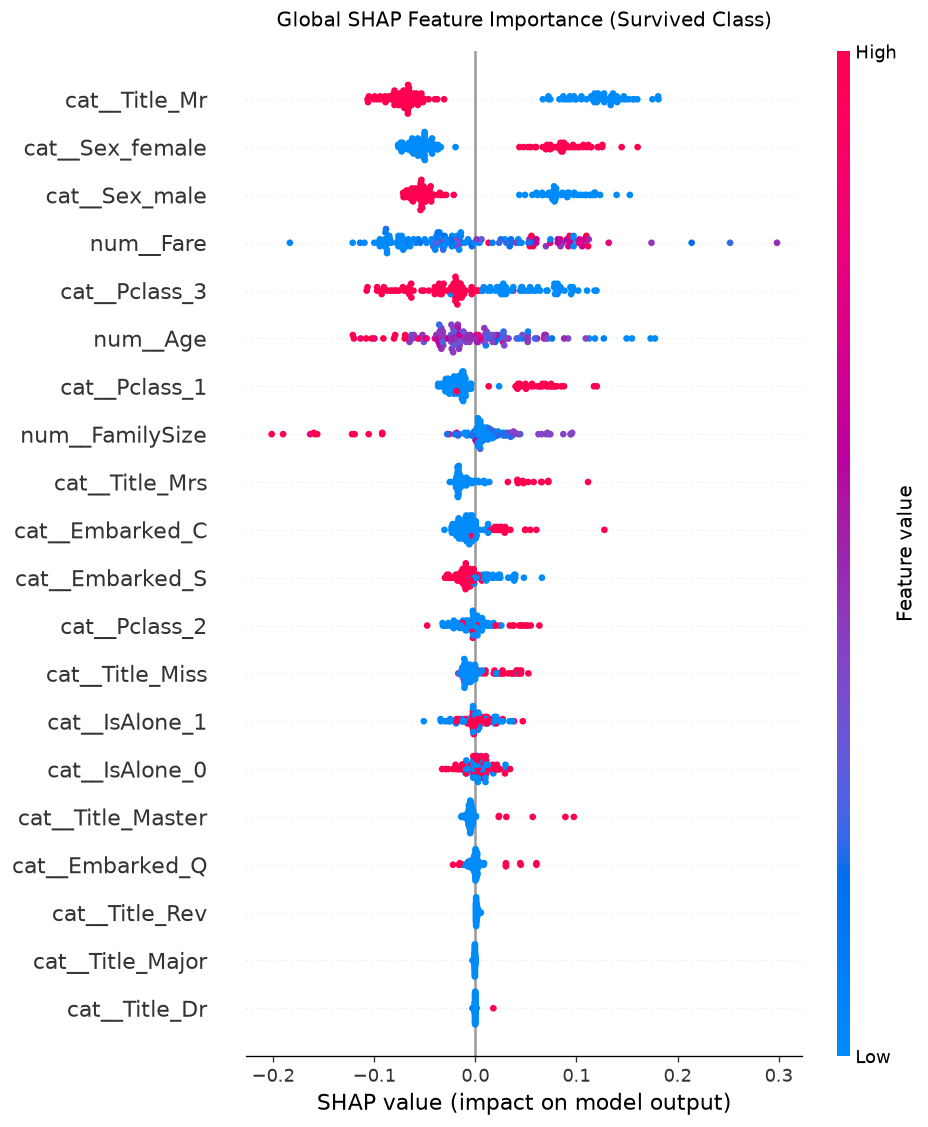


--- Local SHAP Explanation for Sample #0 ---
Actual Class:    1 (Survived)
Predicted Class: 0 (Not Survived) [Probability: 0.9870]

Top 5 Most Influential Features for this prediction:
   Feature Name  Transformed Value  SHAP Value (Survived)
      num__Fare          -0.481501              -0.087461
  cat__Title_Mr           1.000000              -0.081477
  cat__Sex_male           1.000000              -0.057852
cat__Sex_female           0.000000              -0.055137
  cat__Pclass_3           1.000000              -0.035813


In [6]:
# TreeExplainer for Random Forest
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_processed)

# Adapt gracefully across SHAP output formats (list of per-class arrays vs 3D array vs 2D array)
if isinstance(shap_values, list):
    shap_values_survived = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_survived = shap_values[:, :, 1]
else:
    shap_values_survived = shap_values

print(f"SHAP values shape for 'Survived' class: {shap_values_survived.shape}")

# Global summary plot for the 'Survived' class
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_survived,
    X_test_processed,
    feature_names=feature_names,
    show=False,
)
plt.title("Global SHAP Feature Importance (Survived Class)", fontsize=12, pad=15)
plt.tight_layout()
shap_plot_path = reports_dir / "shap_summary.png"
plt.savefig(shap_plot_path, dpi=120, bbox_inches="tight")
plt.close()
print(f"Saved SHAP summary plot to: {shap_plot_path}")
display(Image(filename=str(shap_plot_path)))

# Explain a single prediction (Sample idx = 0)
sample_idx = 0
sample_data = X_test_processed.iloc[sample_idx:sample_idx+1] if isinstance(X_test_processed, pd.DataFrame) else X_test_processed[sample_idx:sample_idx+1]
sample_pred = clf.predict(sample_data)[0]
sample_pred_label = "Survived" if sample_pred == 1 else "Not Survived"
sample_probs = clf.predict_proba(sample_data)[0]
actual_label = "Survived" if y_test.iloc[sample_idx] == 1 else "Not Survived"

print(f"\n--- Local SHAP Explanation for Sample #{sample_idx} ---")
print(f"Actual Class:    {y_test.iloc[sample_idx]} ({actual_label})")
print(f"Predicted Class: {sample_pred} ({sample_pred_label}) [Probability: {sample_probs[sample_pred]:.4f}]")

sample_shap = shap_values_survived[sample_idx]
sample_feature_values = sample_data.values[0] if isinstance(sample_data, pd.DataFrame) else sample_data[0]

feature_shap_df = pd.DataFrame({
    "Feature Name": feature_names,
    "Transformed Value": sample_feature_values,
    "SHAP Value (Survived)": sample_shap,
    "Absolute Impact": np.abs(sample_shap),
}).sort_values(by="Absolute Impact", ascending=False)

print("\nTop 5 Most Influential Features for this prediction:")
print(feature_shap_df[["Feature Name", "Transformed Value", "SHAP Value (Survived)"]].head(5).to_string(index=False))

## Section 6: Save Model

In [7]:
model_path = models_dir / "titanic_rf_classifier.pkl"
joblib.dump(clf, model_path)
print(f"Trained classifier saved to: {model_path}")

print()
print("Model Evaluated Beyond Accuracy")
print("Confusion Matrix and Classification Report Generated")
print("Subgroup Bias Check Completed")
print("SHAP Explainability Report Generated")

Trained classifier saved to: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 10/responsible-ai-evaluation/models/titanic_rf_classifier.pkl

Model Evaluated Beyond Accuracy
Confusion Matrix and Classification Report Generated
Subgroup Bias Check Completed
SHAP Explainability Report Generated


## Section 7: Results Summary

In [8]:
print("### Classification Report Summary")
print(cr_df.to_string())
print("\n### Bias Report Summary by Sex")
print(bias_report.to_string(index=False))
print("\n### Detailed Fairness Metrics by Sex")
print(fairness_df.to_string(index=False))

### Classification Report Summary
              precision    recall  f1-score     support
Not Survived   0.797753  0.855422  0.825581   83.000000
Survived       0.733333  0.647059  0.687500   51.000000
accuracy       0.776119  0.776119  0.776119    0.776119
macro avg      0.765543  0.751240  0.756541  134.000000
weighted avg   0.773235  0.776119  0.773028  134.000000

### Bias Report Summary by Sex
   Sex  accuracy  total_samples  correct_predictions
female  0.791667             48                   38
  male  0.767442             86                   66

### Detailed Fairness Metrics by Sex
   Sex  Accuracy  Precision  Recall  F1-Score  Support
female    0.7917     0.8235  0.8750    0.8485       48
  male    0.7674     0.4545  0.2632    0.3333       86


### Classification Report

| Class | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| Not Survived | 0.7978 | 0.8554 | 0.8256 | 83 |
| Survived | 0.7333 | 0.6471 | 0.6875 | 51 |
| **Accuracy** | | | **0.7761** | **134** |
| Macro Avg | 0.7655 | 0.7512 | 0.7565 | 134 |
| Weighted Avg | 0.7732 | 0.7761 | 0.7730 | 134 |

### Bias & Subgroup Fairness (Sex)

| Group (Sex) | Accuracy | Precision | Recall | F1-Score | Total Samples | Correct Predictions |
| --- | --- | --- | --- | --- | --- | --- |
| female | 0.7917 (79.17%) | 0.8235 | 0.8750 | 0.8485 | 48 | 38 |
| male | 0.7674 (76.74%) | 0.4545 | 0.2632 | 0.3333 | 86 | 66 |

### Checklist

- [x] Model Evaluated Beyond Accuracy
- [x] Confusion Matrix and Classification Report Generated
- [x] Subgroup Bias Check Completed
- [x] SHAP Explainability Report Generated
